<!--
Software Name : learning-parities-with-product-networks
SPDX-FileCopyrightText: Copyright (c) 2026 Orange S.A.
SPDX-License-Identifier: MIT

This software is distributed under the MIT License .,
see the "LICENSE.md" file for more details or https://opensource.org/licenses/MIT

Author: Guillaume Larue, guillaume.larue@orange.com
Software description: Source code of the paper "Learning High-Dimensional Parity Functions with Product Networks"
-->

# Study A — Impact of Dataset Sparsity $p_e$ on Convergence

Explores how the example sparsity $p_e$ affects convergence of the product network, for a fixed problem size $N$ and learning rate $\alpha$.

**Data generated by:** [run_study_A.py](../studies/run_study_A.py)  
**Paper sections:** 
- Section 5.2.2 — Impact of Dataset Sparsity $p_e$ (Figure 3)
- Appendix G.3 — Additional Sparsity Analysis (Figure 22)

| Parameter | Value |
|-----------|-------|
| Problem Size $N$          | 100           |
| Num. Parallel Nodes $P$   | 1000          |
| Learning Rate $\alpha$    | 0.1           |
| Batch Size $M$            | 100           |
| Bernouilli Prob. $p_e$    | [0.001, 0.1]  |
| Max. Steps $S$            | 25000         | 
| Oracle Proportion $p_w$   | 0.5           |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sys
import glob

# Add parent directory to path
sys.path.append('..')

from plotting.plot_utility import plot_metric_vs_param, compute_steps_to_thresholds, setup_plot_style

%matplotlib inline
setup_plot_style()

In [2]:
def get_latest_study_folder(study_prefix):
    pattern = f'../studies/results/{study_prefix}_*/'
    folders = glob.glob(pattern)
    if folders:
        return max(folders)  # Latest by name (timestamp-based)
    return None

mode = 'auto'  # Change to 'manual' to specify your own path

if mode == 'auto':
    results_dir = get_latest_study_folder('A_p_e_impact')
    if results_dir is None:
        raise FileNotFoundError("No Study A results found. Run run_study_A.py first.")
    print(f"Auto-detected folder: {results_dir}")
else:
    results_dir = '../studies/results/A_p_e_impact_XXXXXX_XXXXXX/'
    print(f"Using manual path: {results_dir}")

# Load data
p_e_values = np.load(results_dir + 'p_e_values.npy')
p_diff_matrix = np.load(results_dir + 'p_diff_matrix.npy')
steps_to_convergence = np.load(results_dir + 'steps_to_convergence.npy')

print(f"\np_e range: {p_e_values[0]:.6f} to {p_e_values[-1]:.6f}")
print(f"Number of p_e values: {len(p_e_values)}")
print(f"p_diff_matrix shape: {p_diff_matrix.shape}")

Auto-detected folder: ../studies/results/A_p_e_impact_20260420_195207/

p_e range: 0.001000 to 0.100000
Number of p_e values: 50
p_diff_matrix shape: (50, 25000)


## Error $p_\text{diff}$ vs $p_e$ — Iso-Step Curves

Each curve corresponds to a fixed number of training steps. A lower $p_\text{diff}$ for a given step count indicates faster convergence. The theoretical value $p_e = 1/N = 0.01$ is marked as a dashed vertical line. The minimum of each curve is denoted by the green dashed path. The red hatched area represent the value of $p_e$ under which no improvement better than 10% in $p_\text{diff}$ was observed in the maximum number of steps $S=25{,}000$. 

See Paper Section 5.2.2. Figure 3.


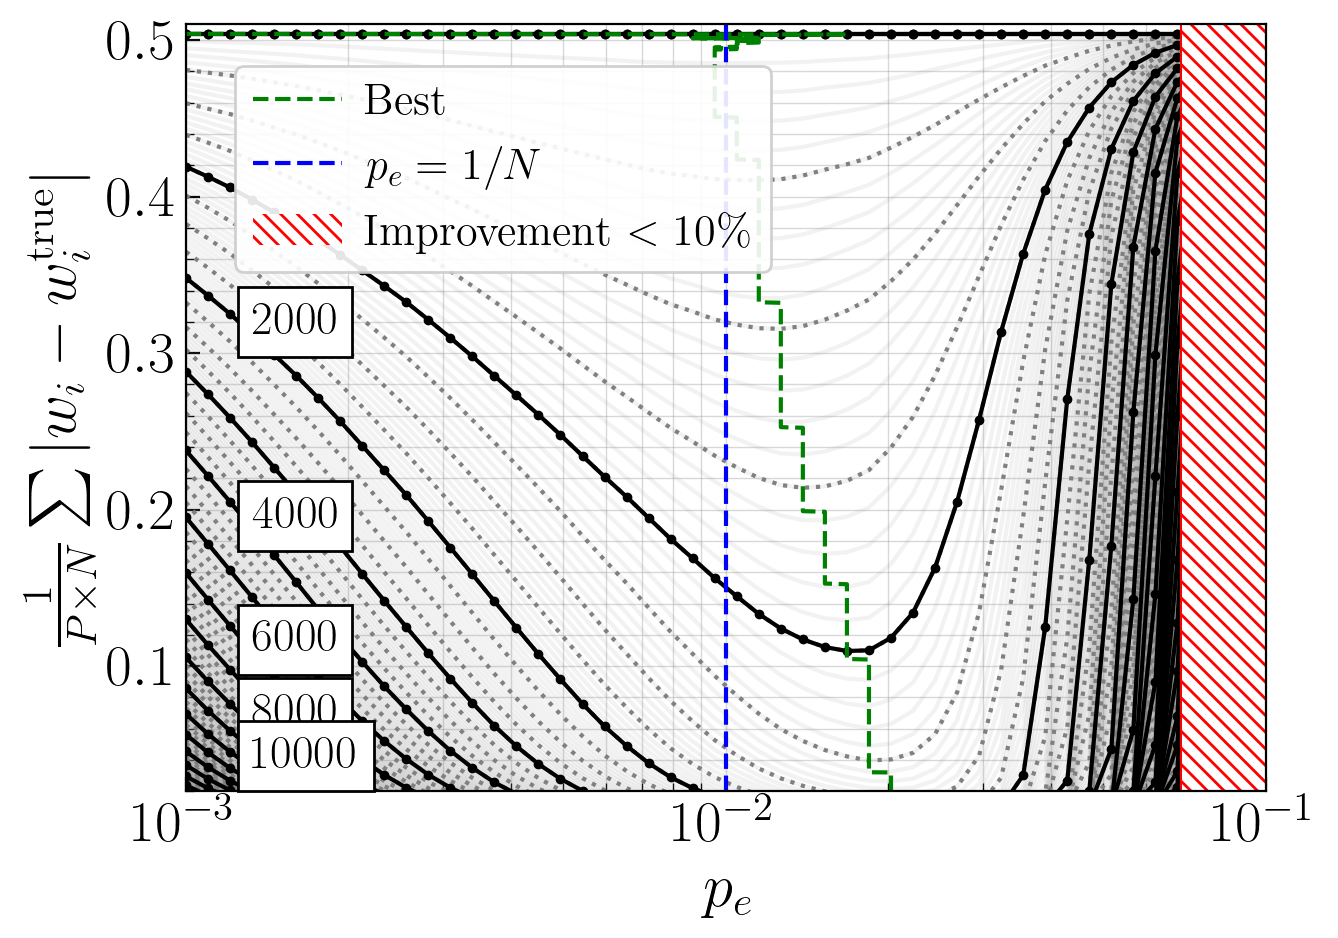

In [3]:
fig, ax = plt.subplots()

plot_metric_vs_param(
    p_e_values,
    p_diff_matrix,
    ax,
    draw_best=True,
    best='min',
    add_min_curve=False,
    xscale='log',
    yscale='linear',
    xlim=(1e-3, 1e-1),
    ylim=(0.02, 0.51)
)

ax.axvline(x=0.01, color='blue', linestyle='--', label='$p_e=1/N$')
ax.set_xlabel('$p_e$')
ax.set_ylabel('$\\frac{1}{P \\times N}\sum|w_i-w_i^\mathrm{true}|$')

ax.axvline(x=7e-2, color='red', linestyle='-')
p = patches.Rectangle((7e-2,0), 1, 10000, linewidth=0, fill=True, fc='white', ec='red', hatch='\\\\\\\\',zorder=2, label='Improvement $<10\%$')
ax.add_patch(p)
ax.legend(loc='upper left', bbox_to_anchor=(0.025,0.975))

plt.tight_layout()
plt.show()


## Steps to Convergence vs $p_e$ — Iso-$p_\text{diff}$ Curves

Each curve corresponds to a fixed convergence threshold $p_\text{diff}=T$. The minimum of each curve identifies the value of $p_e$ requiring the fewest training steps to reach that threshold. 

See Paper Appendix G.3. Figure 22.


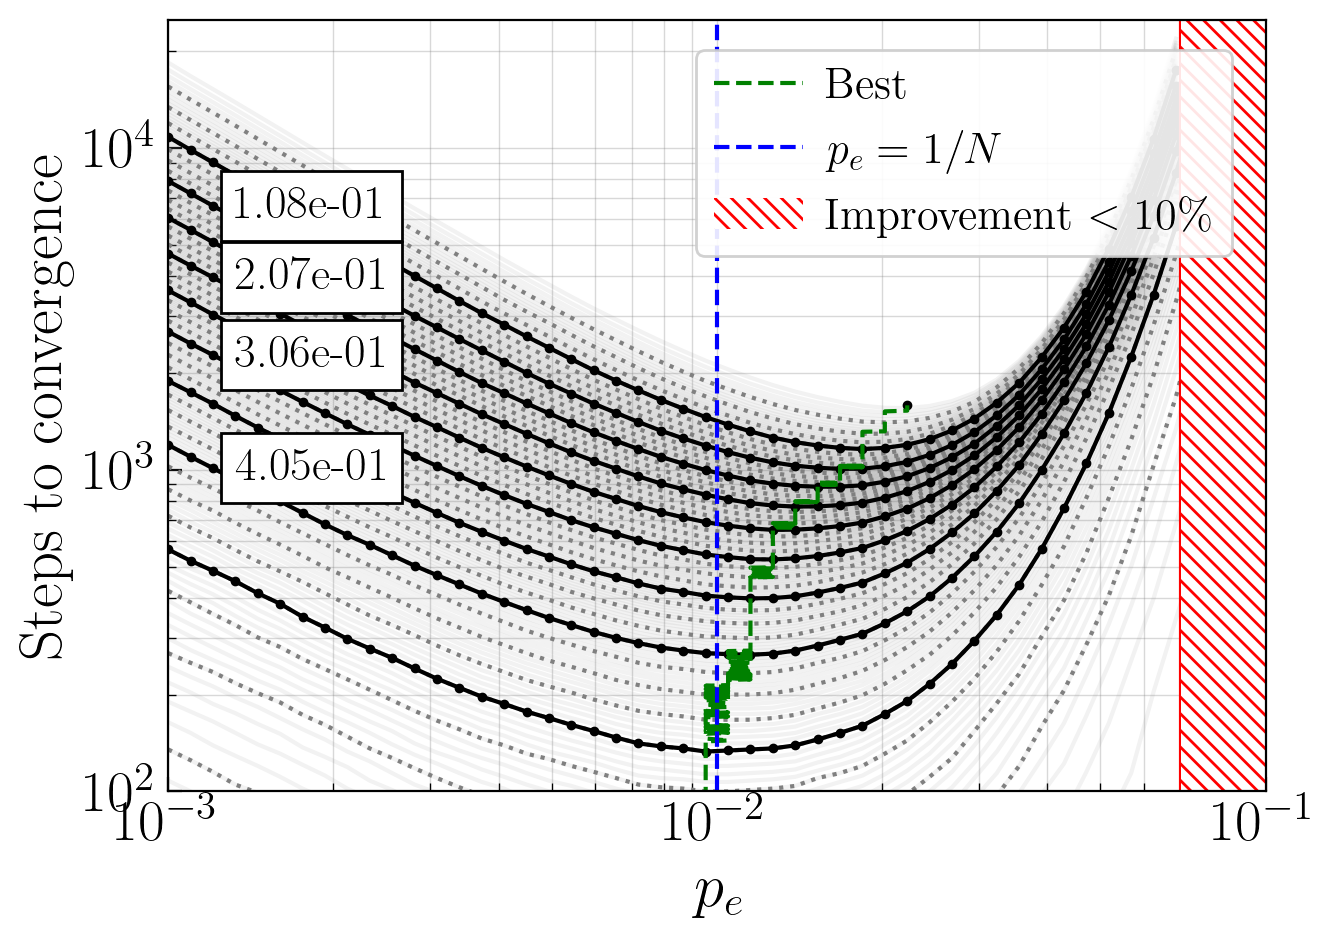

In [4]:
thresholds, steps_data = compute_steps_to_thresholds(p_e_values, p_diff_matrix, n_thresholds=999)

fig, ax = plt.subplots()

plot_metric_vs_param(
    p_e_values,
    steps_data+1,
    ax,
    draw_best=True,
    xscale='log',
    yscale='log',
    xlim=(1e-3, 1e-1),
    ylim=(100, 25_000),
    value_labels=thresholds,
    add_min_curve=False
)

ax.axvline(x=0.01, color='blue', linestyle='--', label='$p_e=1/N$')
ax.set_xlabel('$p_e$')
ax.set_ylabel('Steps to convergence')

ax.axvline(x=7e-2, color='red', linestyle='-')
p = patches.Rectangle((7e-2,0), 1, 25000, linewidth=0, fill=True, fc='white', ec='red', hatch='\\\\\\\\',zorder=2, label='Improvement $<10\%$')
ax.add_patch(p)
ax.legend(loc='upper right', bbox_to_anchor=(0.99,0.99))

plt.tight_layout()
plt.show()
